# **Context About the Dataset**

Here is a cleaner, more academic version:

---

### Dataset Justification

**Data Quality and Structural Properties**

The dataset spans 19 years of continuous monthly records (2001–2019) across all 27 Brazilian states, yielding 228 time steps per state with no missing values across 62 features. Zero sparsity at this scale is uncommon in public health datasets and ensures model performance reflects genuine signal rather than imputation artifacts. The target variable exhibits substantial variance — ranging from 0 to 251,725 cases with a standard deviation of approximately 8,800 — presenting a non-trivial regression problem that resists baseline averaging strategies. Case counts are further disaggregated by age cohort (0–19 and 20–99), capturing demographic vulnerability without collapsing it into a single aggregate figure.

**Feature Relevance**

The feature space covers three epidemiologically distinct domains, each capturing a separate mechanism of dengue transmission.

- **Vector biology** — temperature, precipitation, humidity, dewpoint, and NDVI collectively determine mosquito breeding conditions. Rainfall creates stagnant water pooling, humidity prevents evaporation before larval development completes, and NDVI captures vegetative microhabitats. Temperature alone is insufficient; the interaction between these variables defines the biological threshold for population explosions.

- **Urban infrastructure** — sanitation access (t_sem_agua_esgoto, t_sem_lixo), urban cover percentage, and infrastructure vulnerability index (ivs_infraestrutura_urbana) quantify man-made breeding ground availability. Two states with identical climate profiles can produce vastly different outbreak magnitudes depending on sanitation infrastructure — a distinction weather-only datasets cannot capture.

- **Host availability** — population density, urban-rural stratification, and HDI components contextualise transmission rate relative to human exposure. High mosquito density without dense human populations produces limited spread; these features provide the demographic scaling factor necessary for accurate case prediction.

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. ADVANCED DATA PROCESSING
# ==========================================
def load_and_process_data(filepath):
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values(by=['CD_UF', 'Date'])

    # --- A. Log Transformation (The Foundation) ---
    # We log-transform cases immediately to handle the "exponential" nature of outbreaks
    df['cases_log'] = np.log1p(df['cases_total'])

    # --- B. Feature Engineering ---

    # 1. Autoregression (The "Momentum")
    # Last month's cases (in Log scale)
    df['cases_lag1'] = df.groupby('CD_UF')['cases_log'].shift(1)

    # 2. Weather Lags (The "Cause")
    # Weather affects mosquitoes ~1-2 months later
    df['precip_lag1'] = df.groupby('CD_UF')['total_precipitation_d'].shift(1)
    df['temp_lag1'] = df.groupby('CD_UF')['temperature_2m_d'].shift(1)

    # 3. Moving Averages (The "Trend" - NEW!)
    # Helps the model see if the curve is going Up or Down
    df['cases_rolling_3'] = df.groupby('CD_UF')['cases_log'].transform(lambda x: x.rolling(3).mean().shift(1))
    df['precip_rolling_3'] = df.groupby('CD_UF')['total_precipitation_d'].transform(lambda x: x.rolling(3).mean().shift(1))

    # 4. Seasonality (Cyclic Encoding - NEW!)
    # Maps months 1-12 to a circle. Essential for seasonal diseases.
    df['month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)

    # --- C. Clean Up ---
    df = df.dropna()

    # Define Predictors
    feature_cols = [
        'cases_lag1', 'cases_rolling_3',      # Momentum & Trend
        'precip_lag1', 'precip_rolling_3',    # Rain Drivers
        'temp_lag1',                          # Heat Driver
        'month_sin', 'month_cos',             # Seasonality
        'PopTotal_UF'                         # Population Scale
    ]
    target_col = 'cases_log'

    # --- D. Strict Split & Scaling (No Leakage) ---
    train_mask = df['Year'] < 2018

    X = df[feature_cols].values
    y = df[target_col].values.reshape(-1, 1)

    # Scale based ONLY on Training Data
    scaler = StandardScaler()
    X_train = X[train_mask]
    scaler.fit(X_train) # Fit only on train (Start of normalization)

    X_train = scaler.transform(X[train_mask])
    X_test = scaler.transform(X[~train_mask])

    y_train = y[train_mask]
    y_test = y[~train_mask]

    # Convert to Tensors
    data_dict = {
        'X_train': torch.tensor(X_train, dtype=torch.float32),
        'y_train': torch.tensor(y_train, dtype=torch.float32),
        'X_test': torch.tensor(X_test, dtype=torch.float32),
        'y_test': torch.tensor(y_test, dtype=torch.float32),
        'scaler': scaler,
        'features': feature_cols
    }

    return data_dict

# Run the processing
data = load_and_process_data('Brazil_UF_dengue_monthly.csv')
print(f"Data Processed. Features used: {data['features']}")

Data Processed. Features used: ['cases_lag1', 'cases_rolling_3', 'precip_lag1', 'precip_rolling_3', 'temp_lag1', 'month_sin', 'month_cos', 'PopTotal_UF']


In [ ]:
import torch.nn as nn

class PaperMLP(nn.Module):
    def __init__(self, input_dim):
        super(PaperMLP, self).__init__()

        # Layer 1: Expansion
        self.layer1 = nn.Linear(input_dim, 128) # Wider layer for more patterns
        self.bn1 = nn.BatchNorm1d(128)          # Stabilizes learning
        self.dropout1 = nn.Dropout(0.2)         # Prevents overfitting

        # Layer 2: Refinement
        self.layer2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.1)

        # Layer 3: Compression
        self.layer3 = nn.Linear(64, 32)

        # Output: Regression (Log Cases)
        self.out = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        # Block 2
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        # Block 3
        x = self.layer3(x)
        x = self.relu(x)

        # Output
        x = self.out(x)
        return x

model = PaperMLP(input_dim=len(data['features']))
print(model)

PaperMLP(
  (layer1): Linear(in_features=8, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.1, inplace=False)
  (layer3): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


Starting Training...
Epoch 50 | Loss: 0.4018
Epoch 100 | Loss: 0.3463
Epoch 150 | Loss: 0.3533
Epoch 200 | Loss: 0.3059
Epoch 250 | Loss: 0.3047
Epoch 300 | Loss: 0.3042
Epoch 350 | Loss: 0.2953
Epoch 400 | Loss: 0.2854
Epoch 450 | Loss: 0.3076
Epoch 500 | Loss: 0.2901

FINAL METRICS:
MAE (Error in Cases): 1257
R² (Variance Explained): 0.9194


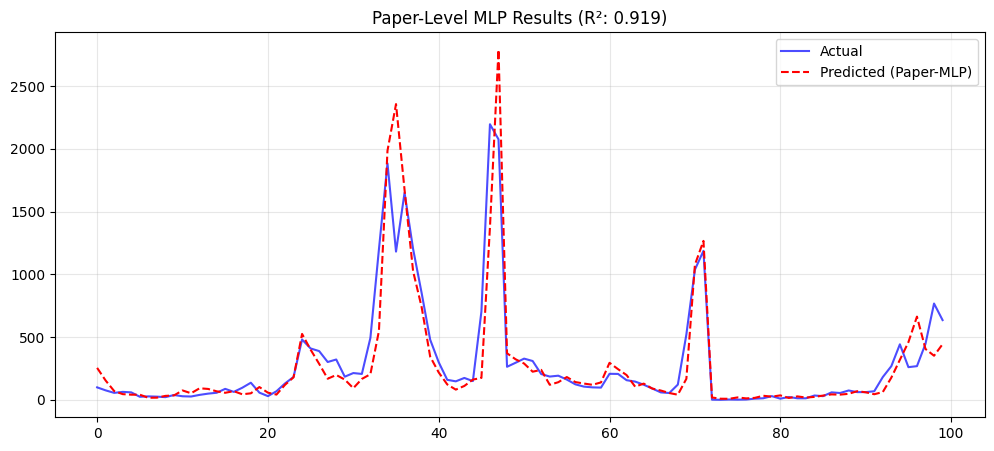

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) # Weight decay helps regularization

print("Starting Training...")
epochs = 500
batch_size = 64 # Mini-batch training is often more stable than full-batch
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(data['X_train'], data['y_train']),
    batch_size=batch_size, shuffle=True
)

# Loop
loss_history = []
model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    loss_history.append(epoch_loss / len(train_loader))

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss_history[-1]:.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    # Predict (Log Scale)
    pred_log = model(data['X_test']).numpy()
    actual_log = data['y_test'].numpy()

    # Inverse Transform (Real Cases)
    pred_real = np.expm1(pred_log)
    actual_real = np.expm1(actual_log)

    # Calculate Metrics
    mae = np.mean(np.abs(pred_real - actual_real))
    r2 = r2_score(actual_log, pred_log)


print(f"\nFINAL METRICS:")
print(f"MAE (Error in Cases): {mae:.0f}")
print(f"R² (Variance Explained): {r2:.4f}")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(actual_real[:100], label='Actual', color='blue', alpha=0.7)
plt.plot(pred_real[:100], label='Predicted (Paper-MLP)', color='red', linestyle='--')
plt.title(f"Paper-Level MLP Results (R²: {r2:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()